In [1]:
import sys
from scipy import sparse
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.io import fits
import scipy.ndimage
from astropy import units as u

from scalesETC.scales import *
from scalesETC.widgets import *
from scalesETC.targs import *



%load_ext autoreload
%autoreload 2

In [2]:
scalesmode = mode_select()
guidestar = gs_select()
scalesmode #use the dropdown to select your mode!

Dropdown(description='Mode:', options=('Low-Res KLM: 2.0-5.2', 'Low-Res K: 1.95-2.45', 'Med-Res K: 1.95-2.45',…

In [3]:
sim = SCALES(scalesmode,guidestar,fullfr=True)

In [5]:
nexps = 1 #total frames to simulate
int_time = 3600 #integration time in seconds per frame

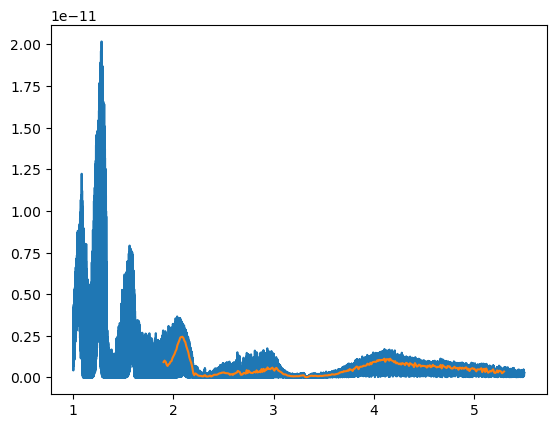

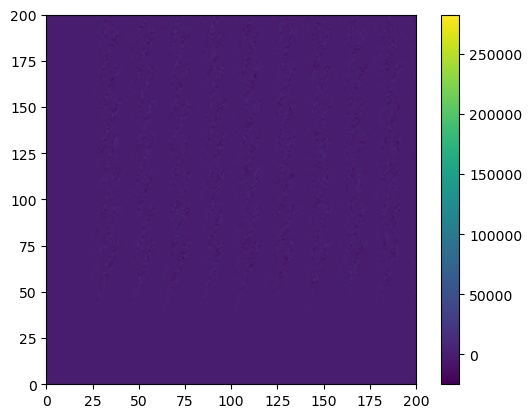

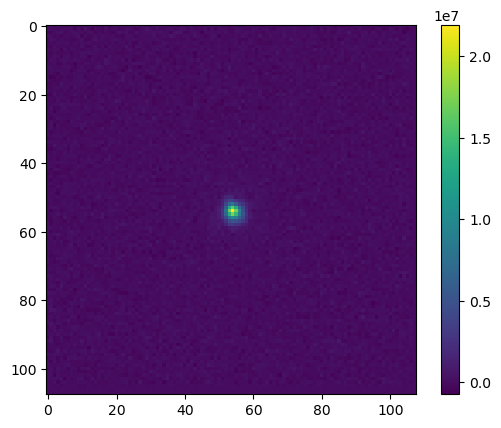

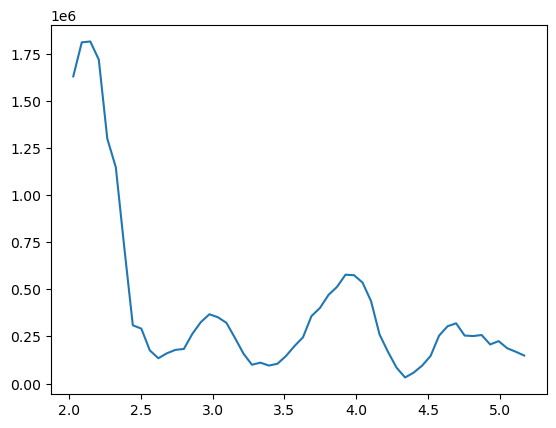

In [12]:
scene_lowres = np.zeros([len(sim.plams),108,108])
plan = sonora_planet(T_p=1000,sg=100,rp=1.6,d=20.0)

scene_lowres[:,54,54]=plan.resample(sim.plams)
plt.plot(plan.x,plan.y)
plt.plot(sim.plams,scene_lowres[:,54,54])
plt.show()

scene_lowres=scene_lowres*u.erg/u.cm/u.cm/u.s/u.um
img_seq, IFScube_seq, rlams = sim.image_and_cube(cube=scene_lowres,nexps=nexps,dit=int_time,shot_off=False)
#img_seq, IFScube_seq, rlams = sim.image_and_cube(targ=plan,nexps=nexps,dit=int_time,shot_off=True)

plt.imshow(img_seq[0])
plt.xlim(0,200)
plt.ylim(0,200)
plt.colorbar()
plt.show()

plt.imshow(np.sum(IFScube_seq[0],axis=0))
plt.colorbar()
plt.show()

plt.plot(rlams,IFScube_seq[0,:,54,54])
plt.show()

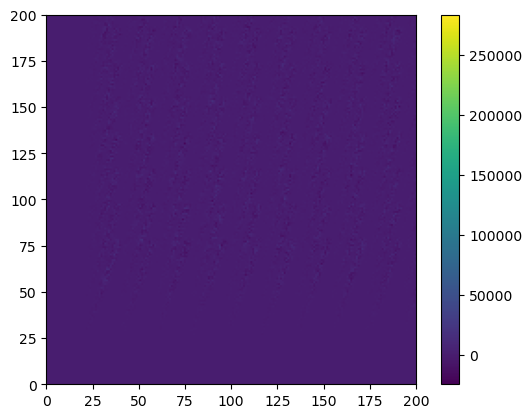

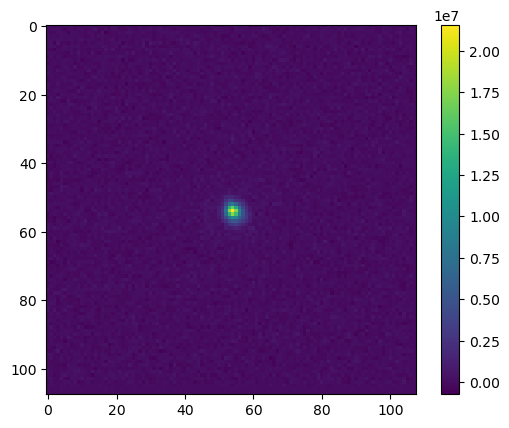

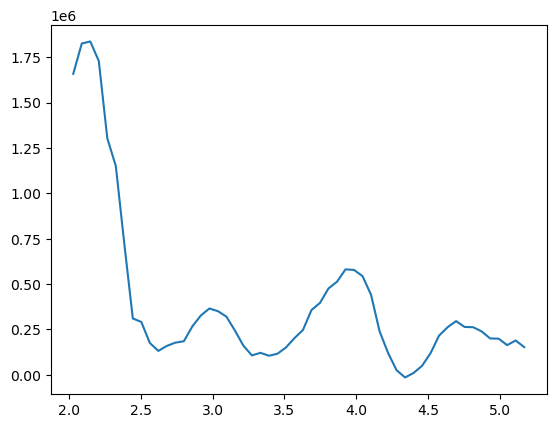

In [13]:
img_seq, IFScube_seq, rlams = sim.image_and_cube(targ=plan,nexps=nexps,dit=int_time,shot_off=False)
plt.imshow(img_seq[0])
plt.xlim(0,200)
plt.ylim(0,200)
plt.colorbar()
plt.show()

plt.imshow(np.sum(IFScube_seq[0],axis=0))
plt.colorbar()
plt.show()

plt.plot(rlams,IFScube_seq[0,:,54,54])
plt.show()